# トークン規格

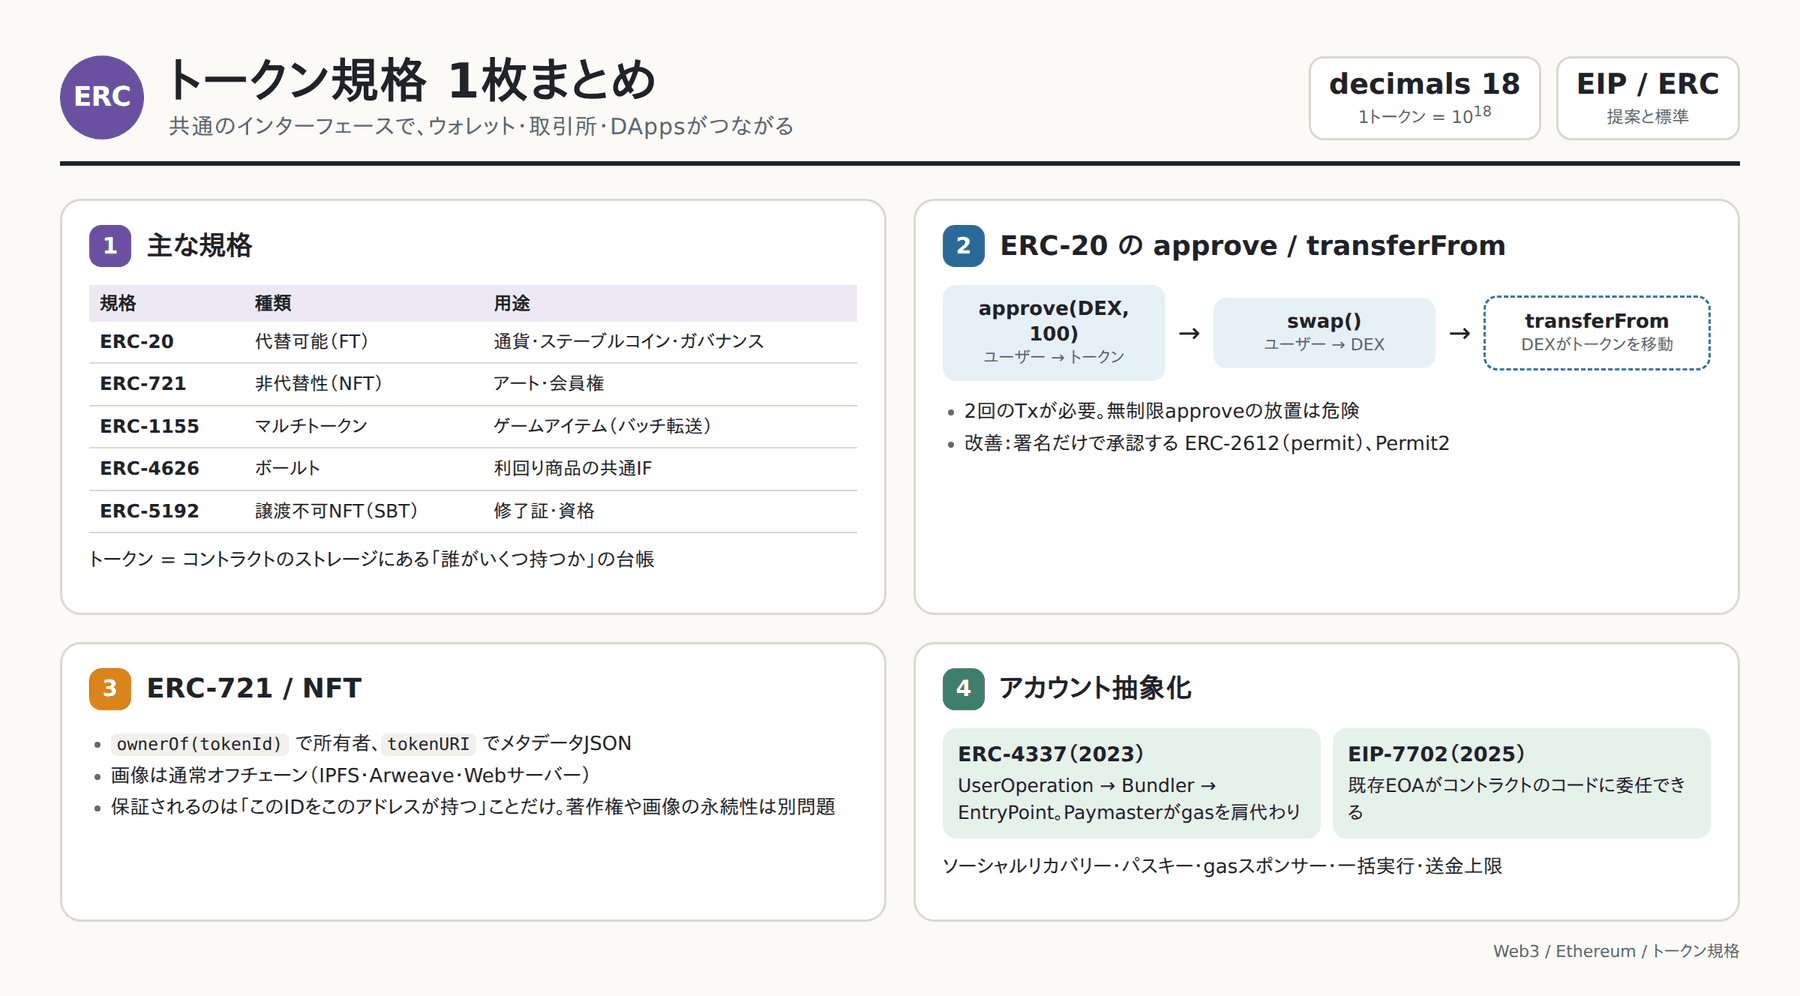

## EIPとERC

Ethereumの仕様変更や標準は **EIP（Ethereum Improvement Proposal）** として提案・議論される。EIPのうち、アプリケーションレベルの標準（トークンのインターフェースなど）を **ERC（Ethereum Request for Comments）** と呼ぶ。

トークンの規格が標準化されているおかげで、異なる開発者が作ったトークン・ウォレット・取引所・DAppsが互いに連携できる。例えば、ERC-20に準拠していれば、新しく作ったトークンでもそのままウォレットに表示でき、DEXで取引できる。

**トークン** は、コントラクトのストレージに記録された「誰がいくつ持っているか」の台帳にすぎない。ETHのようにプロトコルに組み込まれた通貨（ネイティブトークン）とは異なり、ERC-20トークンを送ることは、トークンのコントラクトの `transfer` 関数を呼んでその台帳を書き換えることである。

| 規格 | 種類 | 用途の例 |
| --- | --- | --- |
| ERC-20 | 代替可能トークン（FT） | 通貨、ステーブルコイン、ガバナンストークン |
| ERC-721 | 非代替性トークン（NFT） | アート、ゲームアイテム、会員権 |
| ERC-1155 | マルチトークン | ゲームアイテム、チケット |
| ERC-4626 | トークン化されたボールト | 利回りを生む預け入れの共通インターフェース |
| ERC-5192 | 譲渡不可能なNFT（SBT） | 修了証、資格証明 |

## ERC-20

**ERC-20**（2015年提案）は、代替可能（fungible）なトークン、つまり1枚1枚に区別がなく、同じ量なら同じ価値を持つトークンの規格。

```solidity
interface IERC20 {
    function totalSupply() external view returns (uint256);
    function balanceOf(address account) external view returns (uint256);
    function transfer(address to, uint256 amount) external returns (bool);
    function allowance(address owner, address spender) external view returns (uint256);
    function approve(address spender, uint256 amount) external returns (bool);
    function transferFrom(address from, address to, uint256 amount) external returns (bool);

    event Transfer(address indexed from, address indexed to, uint256 value);
    event Approval(address indexed owner, address indexed spender, uint256 value);
}
```

加えて、任意で `name()`、`symbol()`、`decimals()` を実装する。

### decimals

EVMには小数がないので、トークン量は整数で管理し、`decimals` で表示上の小数点の位置を決める。多くのトークンはETHにならって `decimals = 18` で、「1トークン」は内部的には $10^{18}$ と表す（USDCやUSDTは6）。

### approveとtransferFrom

コントラクト（例えばDEX）にユーザーのトークンを動かしてもらうには、2段階の手順を踏む。

```mermaid
sequenceDiagram
    participant U as ユーザー
    participant T as トークンコントラクト
    participant D as DEXコントラクト
    U->>T: approve(DEX, 100)
    Note over T: allowance[ユーザー][DEX] = 100
    U->>D: swap(...)
    D->>T: transferFrom(ユーザー, DEX, 100)
    Note over T: allowanceを減らして残高を移動
```

コントラクトはETHの送金を受け取ったときのように「トークンを受け取ったこと」を検知できないため、このような仕組みになっている。ただし、

- トランザクションが2回必要で手間とgasがかかる
- 無制限のapprove（`type(uint256).max`）をしたまま放置すると、そのコントラクトに脆弱性が見つかったときに全額を抜き取られる

という問題がある。改善策として、署名だけで承認できる **ERC-2612（permit）** や、Uniswapの **Permit2** がある。

### ストレージの中身

OpenZeppelinのERC-20実装をデプロイしてストレージを覗くと、次のような値が入っている。

| スロット | 内容 |
| --- | --- |
| `keccak256(保有者のアドレス, 0)` | `_balances` マッピングのエントリ（保有者ごとの残高） |
| `1` | `_allowances` マッピングの基準スロット |
| `2` | `_totalSupply` |
| `3` | `_name`（短い文字列はスロットに直接格納される） |
| `4` | `_symbol` |

マッピングの値は、キーとマッピングの基準スロット番号を連結してKeccak-256したスロットに格納される。

## ERC-721

**ERC-721**（2018年）は、1つ1つが固有のIDを持ち区別される **非代替性トークン（NFT, Non-Fungible Token）** の規格。

```solidity
interface IERC721 {
    function balanceOf(address owner) external view returns (uint256);
    function ownerOf(uint256 tokenId) external view returns (address);
    function safeTransferFrom(address from, address to, uint256 tokenId) external;
    function transferFrom(address from, address to, uint256 tokenId) external;
    function approve(address to, uint256 tokenId) external;
    function setApprovalForAll(address operator, bool approved) external;
    // ...
}

interface IERC721Metadata {
    function name() external view returns (string memory);
    function symbol() external view returns (string memory);
    function tokenURI(uint256 tokenId) external view returns (string memory);
}
```

- `ownerOf(tokenId)` で各トークンの所有者を引ける
- `tokenURI(tokenId)` はメタデータ（名前、説明、画像のURLなど）のJSONを指す。画像そのものはサイズが大きいため、通常はオンチェーンには置かず、IPFSやArweave、あるいは普通のWebサーバーに置く
- `safeTransferFrom` は、送り先がコントラクトの場合にNFTを受け取れることを確認する（受け取れないコントラクトに送ってNFTが失われるのを防ぐ）

NFTが保証するのは「このIDのトークンをこのアドレスが持っている」ことだけで、画像の著作権や、画像がずっと同じURLに存在し続けることは保証しない点に注意。

## ERC-1155

**ERC-1155** は、1つのコントラクトで複数の種類のトークンを管理できる **マルチトークン** の規格。トークンIDごとに供給量を持ち、

- 供給量が1なら NFT のように
- 供給量が多ければ FT のように

振る舞う。複数の種類のトークンを1トランザクションでまとめて送れる（バッチ転送）ため、ゲーム内のアイテム（「回復薬×100」と「伝説の剣×1」）など、多種類のトークンを扱う用途で効率がよい。

## その他の規格

| 規格 | 内容 |
| --- | --- |
| ERC-165 | コントラクトがどのインターフェースを実装しているかを問い合わせる仕組み |
| ERC-2612 | 署名（permit）によるapprove。gasを払わずに承認できる |
| ERC-2981 | NFTのロイヤリティ情報の取得方法（支払いの強制まではしない） |
| ERC-4626 | 資産を預けると、持ち分を表すトークンを受け取れるボールトの共通インターフェース。レンディングやステーキングの利回り商品に使われる |
| ERC-5192 | 譲渡できないNFT（**SBT, Soulbound Token**）。資格や実績の証明に使う |
| ERC-6551 | NFT自体にアカウント（ウォレット）を持たせる（Token Bound Account） |

## アカウント抽象化

通常のEOAは「1つの秘密鍵で署名し、ETHでgasを払う」ことしかできない。秘密鍵をなくせば資産を失い、gas代のためにまずETHを手に入れる必要がある。これがWeb3のユーザー体験を悪くしている大きな原因である。

**アカウント抽象化（Account Abstraction）** は、アカウントの振る舞い（署名の検証方法やgasの支払い方）をプログラムで自由に定義できるようにする取り組み。

| 方式 | 内容 |
| --- | --- |
| ERC-4337（2023年稼働） | プロトコルを変えずに、コントラクトウォレット（スマートアカウント）を実現する。ユーザーは `UserOperation` を専用のmempoolに送り、Bundlerがまとめて `EntryPoint` コントラクトに送る。Paymasterが代わりにgasを払うこともできる |
| EIP-7702（2025年、Pectra） | 既存のEOAが、コントラクトのコードを委任先として設定できる。アドレスを変えずにスマートアカウントの機能を使える |

これにより、

- ソーシャルリカバリー（信頼できる友人の承認で鍵を復旧）
- パスキー（生体認証）による署名
- gasの肩代わり（スポンサー）や、ERC-20トークンでのgas支払い
- 複数の操作の一括実行（approve + swap を1回で）
- 1日の送金上限などの制限

といったことが可能になる。